In [1]:
!pip install catboost --quiet

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print('Drive mounted. Your files are at /content/drive/MyDrive/')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 17.8 MB/s eta 0:00:00
Mounted at /content/drive
Drive mounted. Your files are at /content/drive/MyDrive/


In [2]:
import os

DRIVE_FOLDER = '/content/drive/MyDrive/HeartDisease_playground-series-s6e2'

TRAIN_PATH  = os.path.join(DRIVE_FOLDER, 'train.csv')
TEST_PATH   = os.path.join(DRIVE_FOLDER, 'test.csv')
OUTPUT_PATH = os.path.join(DRIVE_FOLDER, 'submission.csv')

# Verify the files exist before going further
for path in [TRAIN_PATH, TEST_PATH]:
    if os.path.exists(path):
        print(f'Found: {path}')
    else:
        print(f'NOT FOUND: {path}  ← Check your DRIVE_FOLDER setting')

Found: /content/drive/MyDrive/HeartDisease_playground-series-s6e2/train.csv
Found: /content/drive/MyDrive/HeartDisease_playground-series-s6e2/test.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import roc_auc_score, roc_curve

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
print('All imports successful')

All imports successful


In [4]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
print('\nFirst 5 rows:')
display(train.head())
print('\nData types:')
print(train.dtypes)
print('\nMissing values:')
print(train.isnull().sum())
print('\nBasic statistics:')
display(train.describe())

Train shape: (630000, 15)
Test shape:  (270000, 14)

First 5 rows:


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence



Data types:
id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object

Missing values:
id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease            

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


Target Distribution

Target Distribution
Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64
Heart Disease
Absence     0.552
Presence    0.448
Name: proportion, dtype: float64


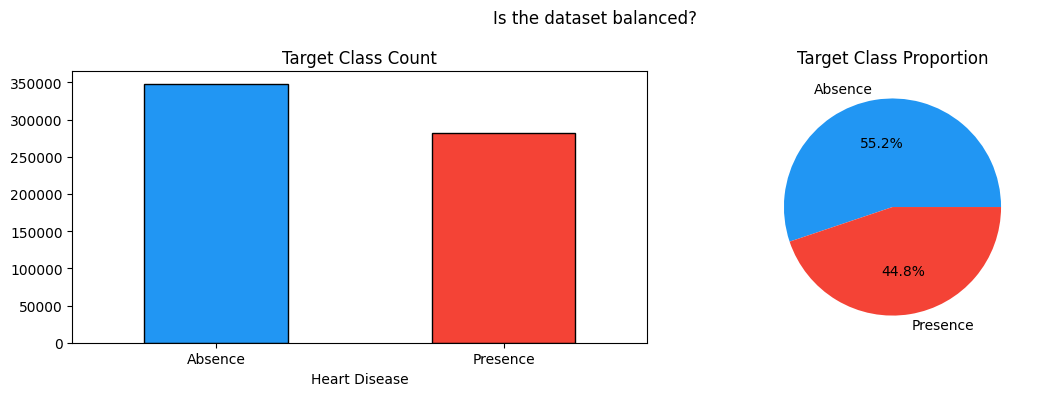

In [5]:
print('Target Distribution')
print(train['Heart Disease'].value_counts())
print(train['Heart Disease'].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train['Heart Disease'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Target Class Count')
axes[0].set_xlabel('Heart Disease')
axes[0].tick_params(axis='x', rotation=0)

train['Heart Disease'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#2196F3', '#F44336'])
axes[1].set_title('Target Class Proportion')
axes[1].set_ylabel('')
plt.suptitle('Is the dataset balanced?')
plt.tight_layout()
plt.show()

Numeric Feature Distribution by Target

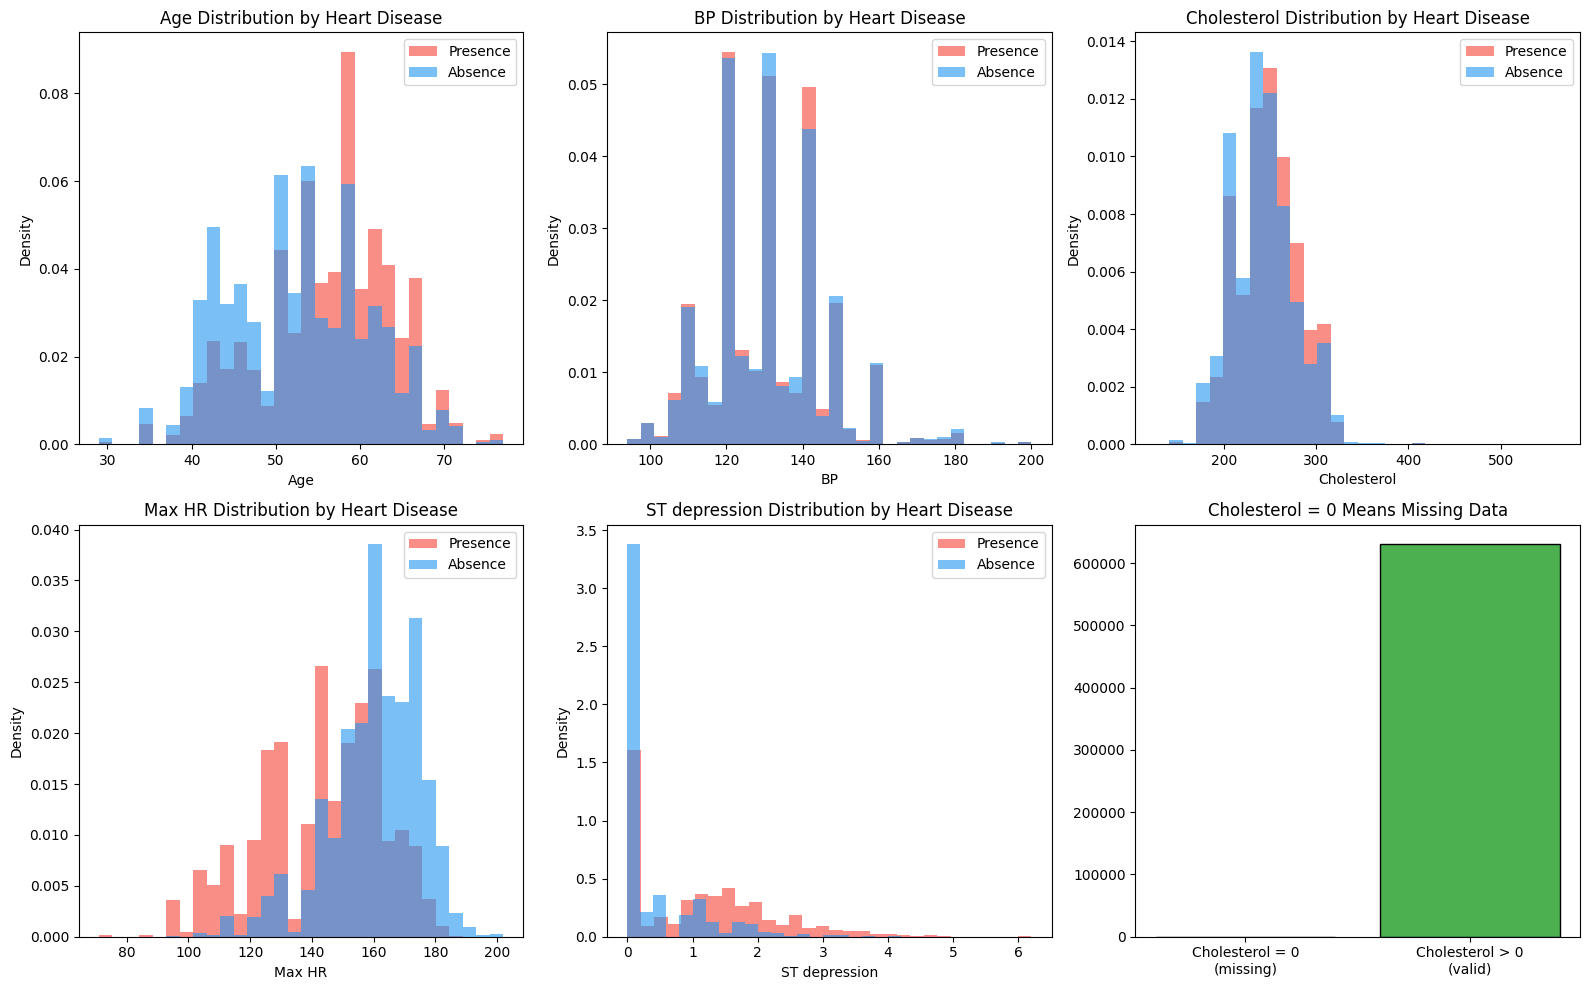

In [6]:
numeric_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color in [('Presence', '#F44336'), ('Absence', '#2196F3')]:
        data = train[train['Heart Disease'] == label][col]
        axes[i].hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(f'{col} Distribution by Heart Disease')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

# Cholesterol = 0 is biologically impossible — it means the value is missing
axes[5].bar(
    ['Cholesterol = 0\n(missing)', 'Cholesterol > 0\n(valid)'],
    [(train['Cholesterol'] == 0).sum(), (train['Cholesterol'] > 0).sum()],
    color=['#FF9800', '#4CAF50'], edgecolor='black'
)
axes[5].set_title('Cholesterol = 0 Means Missing Data')
plt.tight_layout()
plt.show()

Categorical Features vs Target

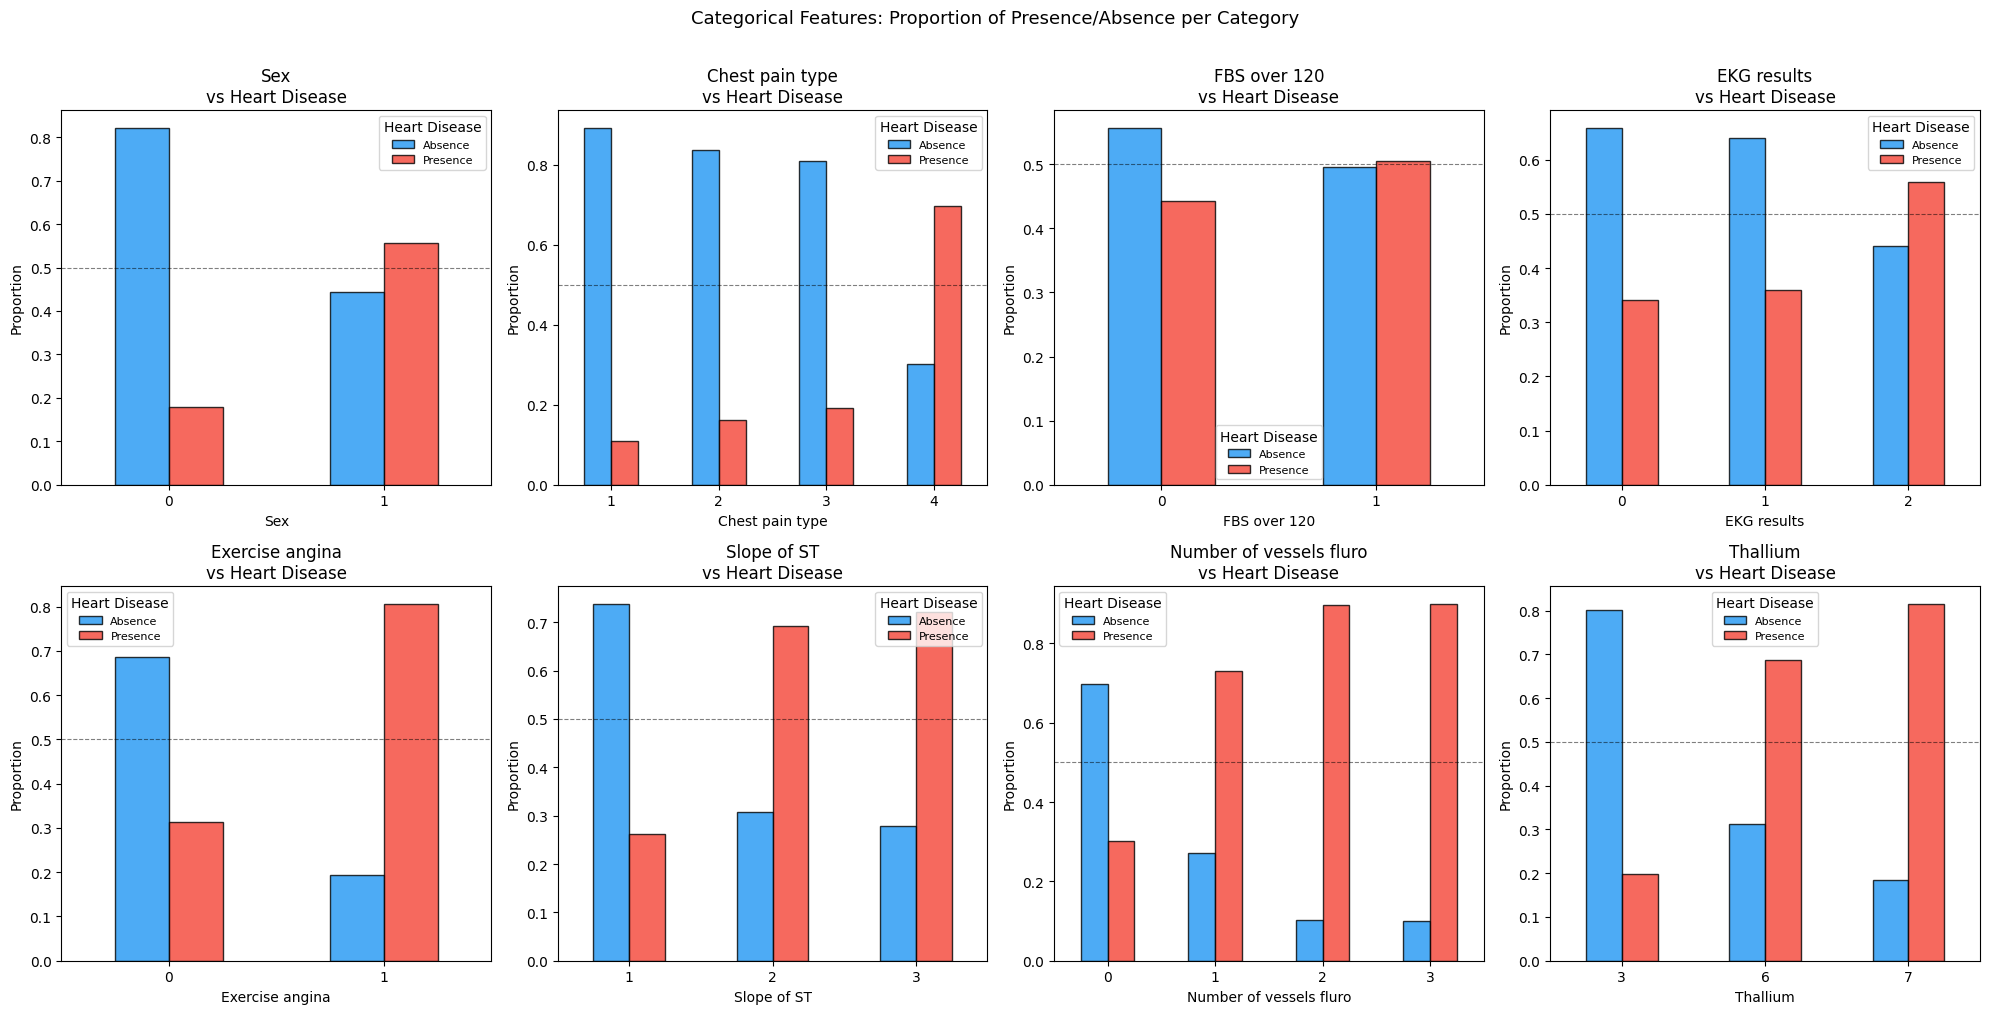

In [7]:
cat_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
            'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # normalize='index': within each category, show % Presence vs Absence
    ct = pd.crosstab(train[col], train['Heart Disease'], normalize='index')
    ct.plot(kind='bar', ax=axes[i], color=['#2196F3', '#F44336'],
            alpha=0.8, edgecolor='black')
    axes[i].set_title(f'{col}\nvs Heart Disease')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Heart Disease', fontsize=8)
    axes[i].axhline(0.5, color='black', linestyle='--', lw=0.8, alpha=0.5)

plt.suptitle('Categorical Features: Proportion of Presence/Absence per Category',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Correlation Heatmap

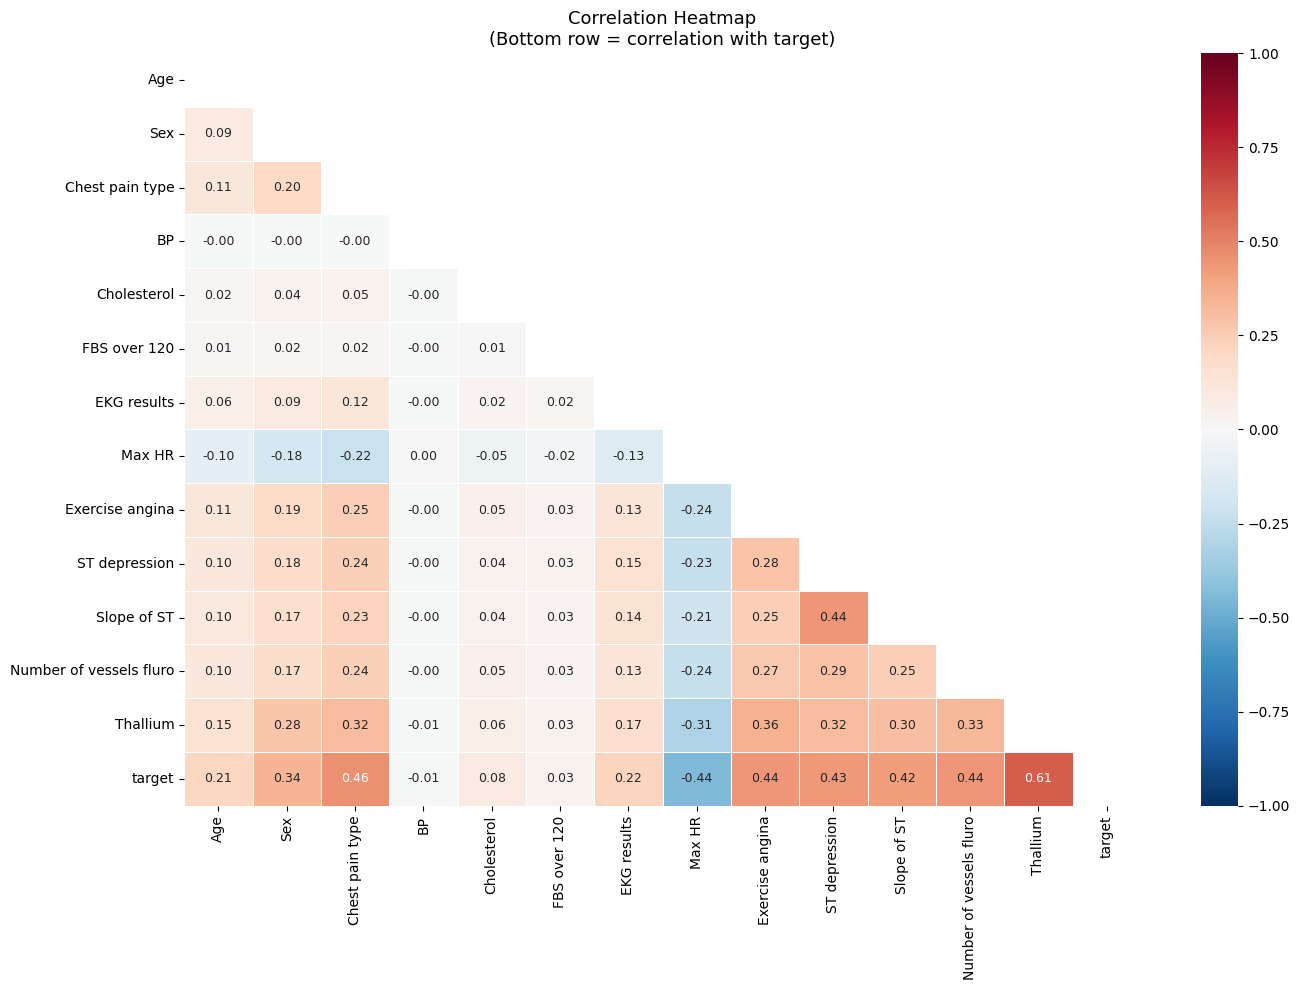

In [8]:
train_corr = train.copy()
train_corr['target'] = (train_corr['Heart Disease'] == 'Presence').astype(int)
train_corr = train_corr.drop(columns=['id', 'Heart Disease'])

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(train_corr.corr(), dtype=bool))
sns.heatmap(
    train_corr.corr(), mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 9}
)
plt.title('Correlation Heatmap\n(Bottom row = correlation with target)', fontsize=13)
plt.tight_layout()
plt.show()

Age vs Max Hr Scatter Plot

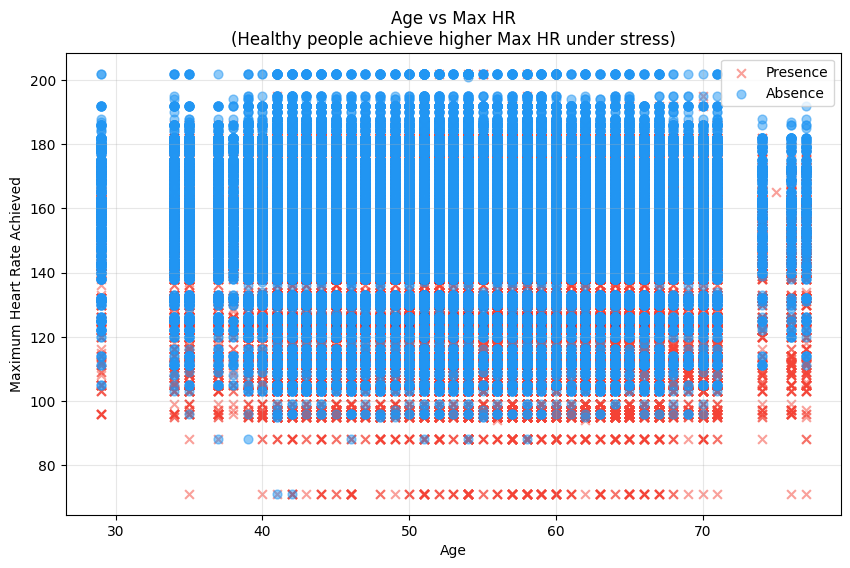

In [9]:
plt.figure(figsize=(10, 6))
for label, color, marker in [('Presence', '#F44336', 'x'),
                               ('Absence',  '#2196F3', 'o')]:
    subset = train[train['Heart Disease'] == label]
    plt.scatter(subset['Age'], subset['Max HR'],
                alpha=0.5, c=color, marker=marker, label=label, s=40)
plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate Achieved')
plt.title('Age vs Max HR\n(Healthy people achieve higher Max HR under stress)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Preprocessing and Feature Engineering

In [10]:
def preprocessing(df, is_train=True, chol_median=None):
  df = df.copy()

  if is_train:
    df['target'] = (df['Heart Disease'] == 'Presence').astype(int)
    df = df.drop(columns=['Heart Disease'])

  ids  = df['id'].copy()
  df = df.drop(columns=['id'])

  # Feature Engineering

  # Heart Rate Reserve
  df['HR_reserve'] = (220 - df['Age']) - df['Max HR']
  df['HR_pct_max'] = df['Max HR'] / (220 - df['Age'])

  # Age bins
  df['Age_bin'] = pd.cut(
      df['Age'], bins = [0,45,55,65,100], labels=[0,1,2,3]
  ).astype(int)

  # Blood PRessure risk categories
  df['BP_risk'] = pd.cut(
      df['BP'], bins = [0,120,130,140,999], labels=[0,1,2,3]
  ).astype(int)

  # ST depression x Slope
  df['ST_slope_product'] = df['ST depression'] * df['Slope of ST']

  # Older patients with exercise-induced angina
  df['age_x_angina'] = df['Age'] * df['Exercise angina']

  # Number of vessels fluro
  df['vessels_x_thallium'] = df['Number of vessels fluro'] * df['Thallium']

  # Chest pain type
  # Type 4 = asymptomatic → paradoxically the highest risk category
  df['chest_pain_severe'] = (df['Chest pain type'] == 4).astype(int)

  # Thallium = 7 = reversible defect → highest risk
  df['thallium_reversible'] = (df['Thallium'] == 7).astype(int)

  # ST depression > 2.0 is clinically significant
  df['ST_high'] = (df['ST depression'] > 2.0).astype(int)

  return df, ids

train_proc, train_ids = preprocessing(train, is_train=True)
test_proc, test_ids = preprocessing(test, is_train=False)

TARGET = 'target'
FEATURES = [c for c in train_proc.columns if c != TARGET]

X = train_proc[FEATURES]
y = train_proc[TARGET]

X_test = test_proc[FEATURES]

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'X shape: {X.shape}')
print(f'Presence rate: {y.mean():.3f}')
print('No KeyErrors — all column names verified')

Features (23): ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'HR_reserve', 'HR_pct_max', 'Age_bin', 'BP_risk', 'ST_slope_product', 'age_x_angina', 'vessels_x_thallium', 'chest_pain_severe', 'thallium_reversible', 'ST_high']
X shape: (630000, 23)
Presence rate: 0.448
No KeyErrors — all column names verified


Define Models

Six base models with different learning strategies:
- XGBoost / LightGBM / CatBoost — gradient boosting (sequential trees)
- RandomForest / ExtraTrees — bagging (many independent trees)
- LogisticRegression — linear model, adds diversity

In [11]:
# Setting estimators
N_EST = 500

models = {
    'XGBoost' : xgb.XGBClassifier(
        n_estimators=N_EST,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_weight=3,
        use_label_encoder=False,
        eval_metric='auc',
        random_state=SEED,
        verbosity=0,
        n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=N_EST,
        max_depth=4,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_samples=20,
        random_state=SEED,
        verbose=-1,
        n_jobs=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=N_EST,
        learning_rate=0.05,
        depth=4,
        l2_leaf_reg=3,
        random_seed=SEED,
        verbose=0,
        thread_count=-1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=N_EST,
        max_depth=8,
        min_samples_leaf=3,
        max_features='sqrt',
        random_state=SEED,
        n_jobs=-1
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=N_EST,
        max_depth=8,
        min_samples_leaf=3,
        max_features='sqrt',
        random_state=SEED,
        n_jobs=-1
    ),
}

# Logistic Regression needs scaled features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURES)

models['LogisticReg'] = LogisticRegression(
    C=0.1,
    max_iter=1000,
    random_state=SEED
    )

print(f'Models defined: {list(models.keys())}')
print(f'n_estimators set to: {N_EST}')

Models defined: ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'ExtraTrees', 'LogisticReg']
n_estimators set to: 500


OOF (Out-Of-Fold) Training Function

In [12]:
def get_oof_predictions(model_name, model, X_tr, y_tr, X_te, seeds, skf):
  n_train = len(X_tr)
  n_test = len(X_te)

  oof_accum = np.zeros(n_train)
  test_accum = np.zeros(n_test)

  for seed in seeds:
    oof_this_seed = np.zeros(n_train)
    test_this_seed = np.zeros(n_test)

    if hasattr(model, 'set_params'):
      if 'random_state' in model.get_params():
          model.set_params(random_state=seed)
      elif 'random_seed' in model.get_params():
          model.set_params(random_seed=seed)

    fold_aucs = []

    for fold_num, (tr_idx, val_idx) in enumerate(skf.split(X_tr, y_tr)):
        X_fold_train = X_tr.iloc[tr_idx]    # 90% of data — model trains on this
        X_fold_val   = X_tr.iloc[val_idx]   # 10% of data — model predicts this
        y_fold_train = y_tr.iloc[tr_idx]
        y_fold_val   = y_tr.iloc[val_idx]

        model.fit(X_fold_train, y_fold_train)

        # predict_proba → [P(Absence), P(Presence)], we want column 1
        oof_this_seed[val_idx] = model.predict_proba(X_fold_val)[:, 1]

        # Accumulate test predictions across all folds (will average at end)
        test_this_seed += model.predict_proba(X_te)[:, 1] / skf.n_splits

        fold_auc = roc_auc_score(y_fold_val, oof_this_seed[val_idx])
        fold_aucs.append(fold_auc)
        print(f'    Fold {fold_num+1}/10 AUC: {fold_auc:.4f}')

        seed_auc = roc_auc_score(y_tr, oof_this_seed)
        print(f'  [{model_name}] Seed {seed} | OOF AUC: {seed_auc:.5f}\n')

        oof_accum  += oof_this_seed
        test_accum += test_this_seed

    # Average across all seeds
    oof_final  = oof_accum  / len(seeds)
    test_final = test_accum / len(seeds)

    overall_auc = roc_auc_score(y_tr, oof_final)
    print(f'  [{model_name}] FINAL OOF AUC ({len(seeds)} seeds avg): {overall_auc:.5f}\n')
    print('='*60)

    return oof_final, test_final

print('OOF function defined')

OOF function defined


Train all Models

In [13]:
SKF   = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
SEEDS = [42, 123, 456]   # increase to [42,123,456,789,2024] for final submission

oof_results  = {}  # OOF predictions per model — used as meta-features for stacking
test_results = {}  # Test predictions per model

for name, model in models.items():
    print(f'Training: {name}')

    # Logistic Regression uses scaled features
    X_input = X_scaled if name == 'LogisticReg' else X
    X_test_input = X_test_scaled if name == 'LogisticReg' else X_test

    oof, test_pred = get_oof_predictions(
        name, model, X_input, y, X_test_input, SEEDS, SKF
    )
    oof_results[name]  = oof
    test_results[name] = test_pred

print('INDIVIDUAL MODEL OOF AUC SUMMARY')
for name, oof in oof_results.items():
    print(f'  {name:<20}: {roc_auc_score(y, oof):.5f}')

Training: XGBoost
    Fold 1/10 AUC: 0.9551
  [XGBoost] Seed 42 | OOF AUC: 0.50455

    Fold 2/10 AUC: 0.9560
  [XGBoost] Seed 42 | OOF AUC: 0.51823

    Fold 3/10 AUC: 0.9551
  [XGBoost] Seed 42 | OOF AUC: 0.54099

    Fold 4/10 AUC: 0.9541
  [XGBoost] Seed 42 | OOF AUC: 0.57282

    Fold 5/10 AUC: 0.9556
  [XGBoost] Seed 42 | OOF AUC: 0.61380

    Fold 6/10 AUC: 0.9551
  [XGBoost] Seed 42 | OOF AUC: 0.66387

    Fold 7/10 AUC: 0.9539
  [XGBoost] Seed 42 | OOF AUC: 0.72295

    Fold 8/10 AUC: 0.9559
  [XGBoost] Seed 42 | OOF AUC: 0.79127

    Fold 9/10 AUC: 0.9562
  [XGBoost] Seed 42 | OOF AUC: 0.86873

    Fold 10/10 AUC: 0.9553
  [XGBoost] Seed 42 | OOF AUC: 0.95522

  [XGBoost] FINAL OOF AUC (3 seeds avg): 0.91156

Training: LightGBM
    Fold 1/10 AUC: 0.9551
  [LightGBM] Seed 42 | OOF AUC: 0.50455

    Fold 2/10 AUC: 0.9561
  [LightGBM] Seed 42 | OOF AUC: 0.51823

    Fold 3/10 AUC: 0.9551
  [LightGBM] Seed 42 | OOF AUC: 0.54099

    Fold 4/10 AUC: 0.9541
  [LightGBM] Seed 42 | OO

Stacking

Train 7th model with 6 models' OOF predictions

In [14]:
# Build meta-feature matrix: shape (n_train, 6) — one column per base model
meta_train = np.column_stack(list(oof_results.values()))
meta_test = np.column_stack(list(test_results.values()))

print(f'Meta-feature matrix shape: {meta_train.shape}')
print(f'Columns: {list(oof_results.keys())}')

# Scale meta features — LR is sensitive to magnitude
# fit_transform on train, transform only on test (no leakage)
meta_scaler = StandardScaler()
meta_train_sc = meta_scaler.fit_transform(meta_train)
meta_test_sc = meta_scaler.transform(meta_test)

# Evaluate meta-model with cross-validation
meta_model = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
meta_cv = cross_val_score(meta_model, meta_train_sc, y,
                              cv=SKF, scoring='roc_auc', n_jobs=-1)
print(f'\nMeta-model CV AUC: {meta_cv.mean():.5f} ± {meta_cv.std():.5f}')

# Fit on all meta-train data, predict test
meta_model.fit(meta_train_sc, y)
stack_test_preds = meta_model.predict_proba(meta_test_sc)[:, 1]

# Which base model does the meta-learner trust most?
coef_df = pd.DataFrame({
    'Model': list(oof_results.keys()),
    'Coefficient': meta_model.coef_[0]
}).sort_values('Coefficient', ascending=False)
print('\nMeta-model coefficients (higher = more trusted by meta-learner):')
display(coef_df)

Meta-feature matrix shape: (630000, 6)
Columns: ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'ExtraTrees', 'LogisticReg']

Meta-model CV AUC: 0.94587 ± 0.00262

Meta-model coefficients (higher = more trusted by meta-learner):


,Model,Coefficient
2,CatBoost,1.155086
0,XGBoost,1.048684
1,LightGBM,0.976355
5,LogisticReg,0.573853
3,RandomForest,0.340001
4,ExtraTrees,-1.848807


Visualization

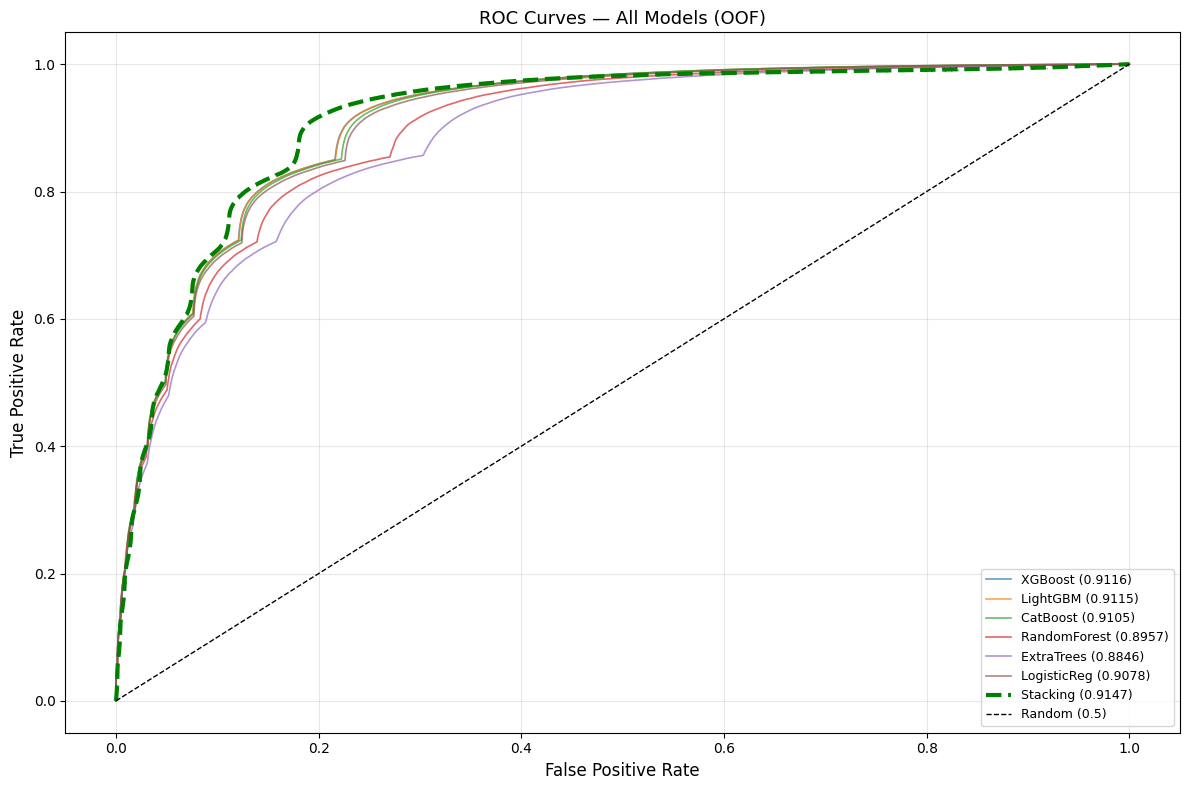

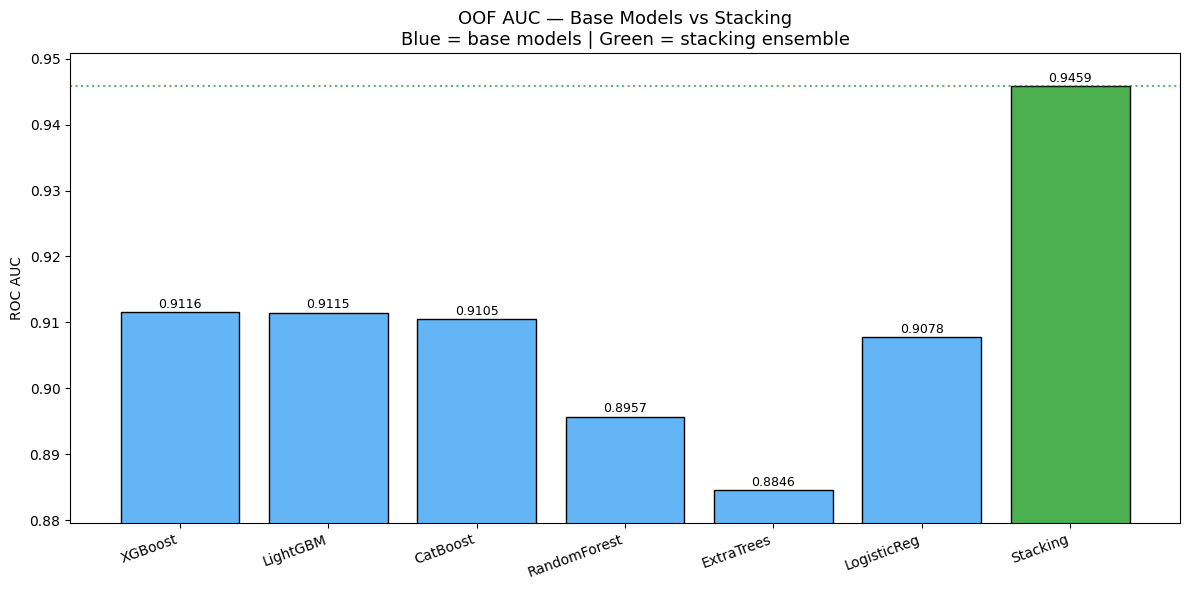

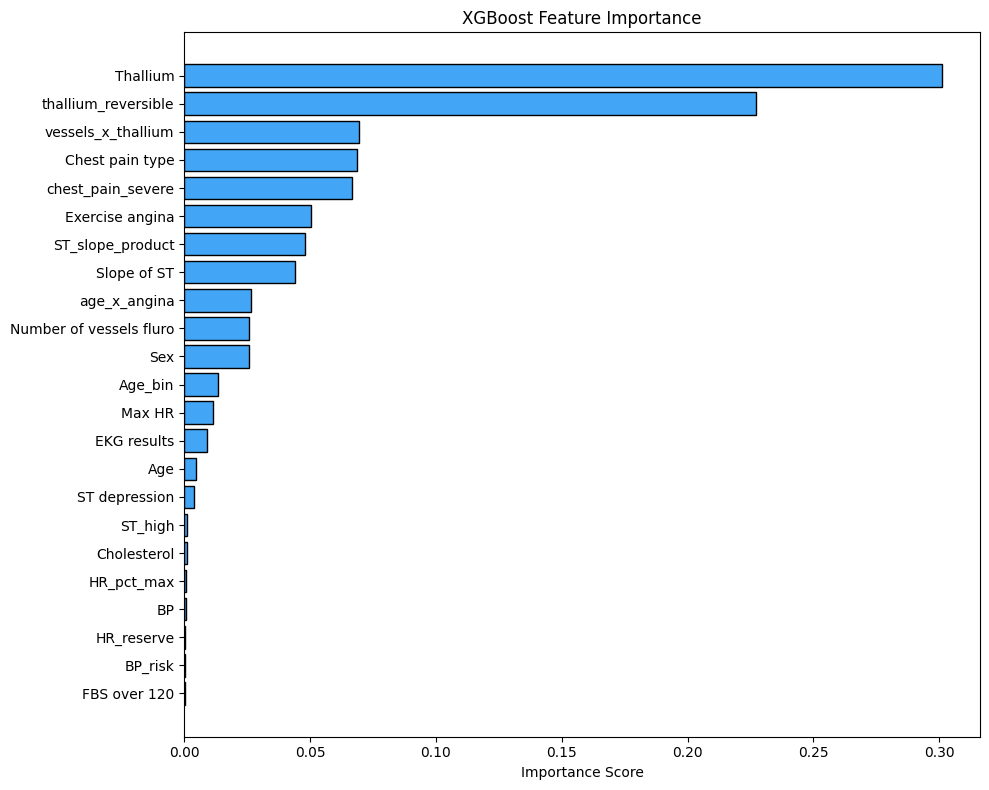

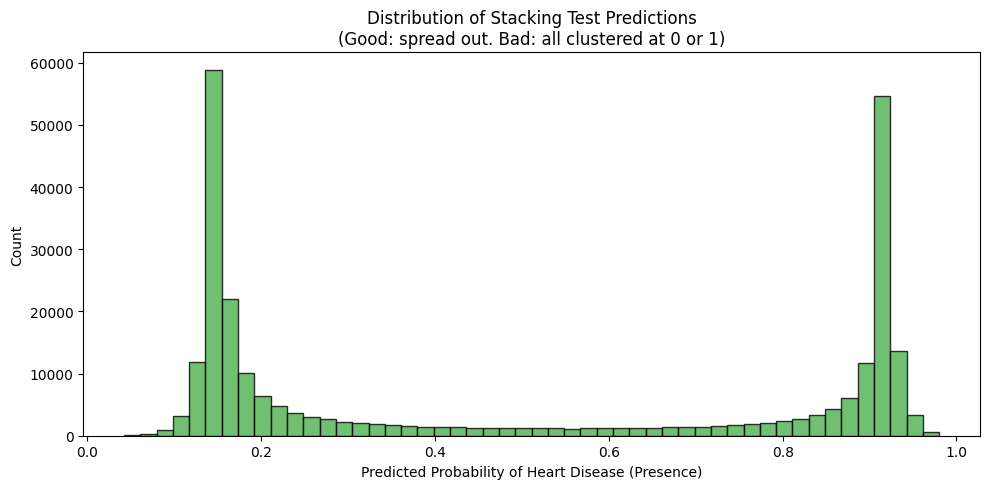

In [17]:
oof_aucs = {name: roc_auc_score(y, oof) for name, oof in oof_results.items()}
stack_auc = meta_cv.mean()

# ROC Curves
plt.figure(figsize=(12, 8))

# Individual base models
for name, oof in oof_results.items():
    fpr, tpr, _ = roc_curve(y, oof)
    auc = roc_auc_score(y, oof)
    plt.plot(fpr, tpr, lw=1.2, alpha=0.7, label=f'{name} ({auc:.4f})')

# Stacking on top
stack_oof = meta_model.predict_proba(meta_train_sc)[:, 1]
fpr, tpr, _ = roc_curve(y, stack_oof)
plt.plot(fpr, tpr, lw=3, linestyle='--', color='green',
         label=f'Stacking ({roc_auc_score(y, stack_oof):.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models (OOF)', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# AUC Comparison Bar Chart
all_aucs = {**oof_aucs, 'Stacking': stack_auc}

plt.figure(figsize=(12, 6))
colors = ['#64B5F6'] * len(oof_aucs) + ['#4CAF50']
bars = plt.bar(all_aucs.keys(), all_aucs.values(), color=colors, edgecolor='black')
plt.ylim(min(all_aucs.values()) - 0.005, max(all_aucs.values()) + 0.005)
plt.axhline(max(all_aucs.values()), color='green', linestyle=':', alpha=0.6)
for bar, val in zip(bars, all_aucs.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.title('OOF AUC — Base Models vs Stacking\nBlue = base models | Green = stacking ensemble',
          fontsize=13)
plt.ylabel('ROC AUC')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Feature Importance
final_xgb = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='auc',
    random_state=SEED, verbosity=0, n_jobs=-1
)
final_xgb.fit(X, y)

importance_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': final_xgb.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='#42A5F5', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

# Prediction Distribution
plt.figure(figsize=(10, 5))
plt.hist(stack_test_preds, bins=50, color='#4CAF50', edgecolor='black', alpha=0.8)
plt.xlabel('Predicted Probability of Heart Disease (Presence)')
plt.ylabel('Count')
plt.title('Distribution of Stacking Test Predictions\n'
          '(Good: spread out. Bad: all clustered at 0 or 1)')
plt.tight_layout()
plt.show()

Submission.csv

In [18]:
print(f'Stacking OOF AUC: {stack_auc:.5f}')
print('Using: Stacking (Logistic Regression meta-learner on 6 base model OOF predictions)')

submission = pd.DataFrame({
    'id':            test_ids,
    'Heart Disease': stack_test_preds
})

# Sanity checks
assert submission.shape[0] == len(test),                'Row count mismatch!'
assert submission['Heart Disease'].between(0, 1).all(), 'Probabilities out of range!'
assert submission.isnull().sum().sum() == 0,            'Null values found!'
print('All sanity checks passed')

# Save to Colab
submission.to_csv('/content/submission.csv', index=False)
print('Saved: /content/submission.csv')

# Save to Google Drive
submission.to_csv(OUTPUT_PATH, index=False)
print(f'Saved to Drive: {OUTPUT_PATH}')

print(f'\nShape: {submission.shape}')
display(submission.head(10))

Stacking OOF AUC: 0.94587
Using: Stacking (Logistic Regression meta-learner on 6 base model OOF predictions)
All sanity checks passed
Saved: /content/submission.csv
Saved to Drive: /content/drive/MyDrive/HeartDisease_playground-series-s6e2/submission.csv

Shape: (270000, 2)


,id,Heart Disease
0,630000,0.949694
1,630001,0.147927
2,630002,0.912077
3,630003,0.144548
4,630004,0.164899
5,630005,0.915925
6,630006,0.133145
7,630007,0.731342
8,630008,0.915354
9,630009,0.150241


Final Summary

In [19]:
print('FINAL SUMMARY')

print(f'\nTraining rows  : {len(X):,}')
print(f'Test rows      : {len(X_test):,}')
print(f'Features used  : {len(FEATURES)}')
print(f'CV folds       : 10 (Stratified K-Fold)')
print(f'Seeds per model: {len(SEEDS)}')
print(f'n_estimators   : {N_EST}')
print(f'\nBase Model OOF AUCs:')
for name, auc in sorted(oof_aucs.items(), key=lambda x: -x[1]):
    print(f'  {name:<20}: {auc:.5f}')
print(f'\n  {"Stacking":<20}: {stack_auc:.5f}  ← SUBMITTED')

FINAL SUMMARY

Training rows  : 630,000
Test rows      : 270,000
Features used  : 23
CV folds       : 10 (Stratified K-Fold)
Seeds per model: 3
n_estimators   : 500

Base Model OOF AUCs:
  XGBoost             : 0.91156
  LightGBM            : 0.91148
  CatBoost            : 0.91047
  LogisticReg         : 0.90777
  RandomForest        : 0.89570
  ExtraTrees          : 0.88457

  Stacking            : 0.94587  ← SUBMITTED
